In [1]:
import pandas as pd

from utils.normalize import smooth

data_path = './data/control/mk1/cortex_control_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place4_1.txt'
# data_path = '/home/noda/Projects/romans-spectors/data/endo/mend1/cortex_endo_1group_633nm_center1500_obj100_power100_1s_5acc_map35x15_step2_place1_1.txt'
data_path = '/home/noda/Projects/romans-spectors/data/endo/mend2b/cortex_left_endo_2Bgroup_633nm_center2900_obj100_power100_1s_5acc_map35x15_step2_place1_1.txt'
columns = ['X', 'Y', 'Wave', 'Intensity']

df = pd.read_csv(data_path, sep='\s+', names=columns, header=0)


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_46175/2949502790.py:10: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(data_path, sep='\s+', names=columns, header=0)


In [2]:
print(df.head())

              X            Y         Wave    Intensity
0  12691.766144 -5389.735833  3288.228516  5437.954590
1  12691.766144 -5389.735833  3287.485352  5464.975586
2  12691.766144 -5389.735833  3286.741211  5470.718750
3  12691.766144 -5389.735833  3285.998047  5449.448730
4  12691.766144 -5389.735833  3285.254883  5326.914551


In [3]:
unique_x, unique_y = list(set(df['X'])), list(set(df['Y']))

In [4]:
result = []

for x in unique_x:
    for y in unique_y:
        dot_df = df[(df['X'] == x) & (df['Y'] == y)]
        result.append(dot_df[['Wave', 'Intensity']])

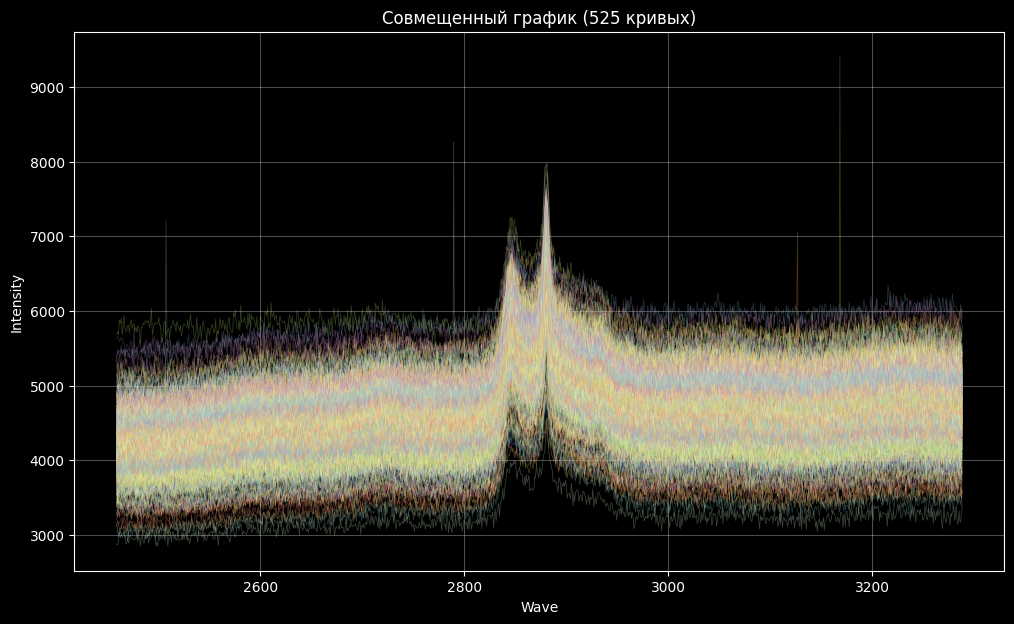

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Перебираем все DataFrame из вашего списка result
for i, data in enumerate(result):
    # Рисуем тонкой линией с прозрачностью, чтобы видеть наложения
    plt.plot(data['Wave'], data['Intensity'], alpha=0.3, linewidth=0.5)

plt.title(f"Совмещенный график ({len(result)} кривых)")
plt.xlabel("Wave")
plt.ylabel("Intensity")
plt.grid(True, alpha=0.3)
plt.show()

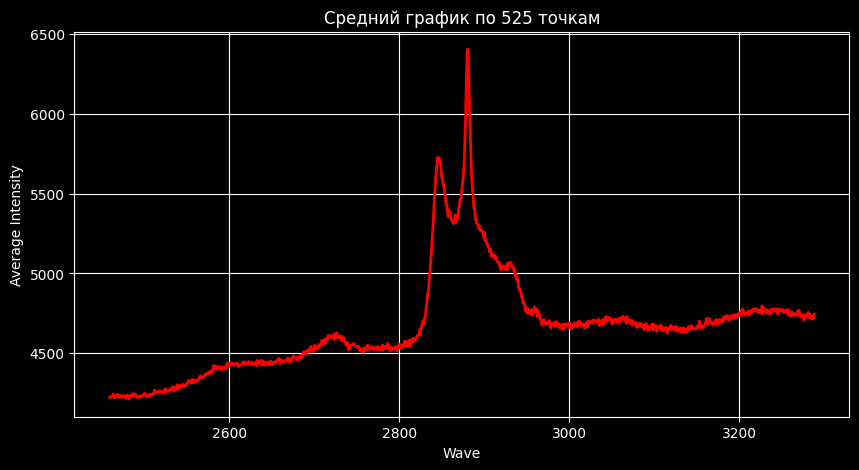

In [6]:
mean_spectrum = df.groupby('Wave')['Intensity'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(mean_spectrum['Wave'], mean_spectrum['Intensity'], color='red', linewidth=2)
plt.title(f"Средний график по {len(result)} точкам")
plt.xlabel("Wave")
plt.ylabel("Average Intensity")
plt.grid(True)
plt.show()

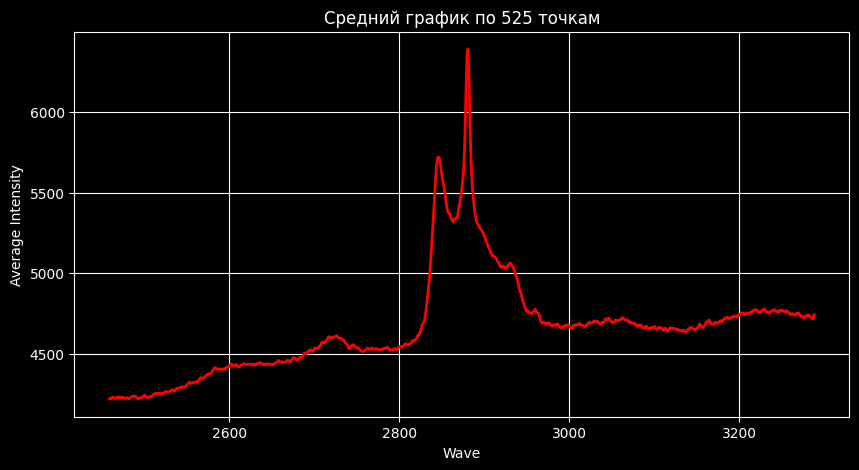

In [7]:
from scipy.signal import savgol_filter
from utils.normalize import smooth

mean_spectrum = df.groupby('Wave')['Intensity'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(mean_spectrum['Wave'], smooth(mean_spectrum['Intensity'], window_length=7, polyorder=3), color='red', linewidth=2)
plt.title(f"Средний график по {len(result)} точкам")
plt.xlabel("Wave")
plt.ylabel("Average Intensity")
plt.grid(True)
plt.show()

In [93]:
import pandas as pd
from scipy.signal import find_peaks

indices, properties = find_peaks(mean_spectrum['Intensity'], prominence=50)

all_peaks = pd.DataFrame({
    'Wave': mean_spectrum['Wave'].iloc[indices].values,
    'Intensity': mean_spectrum['Intensity'].iloc[indices].values,
    'Prominence': properties['prominences']
})

N = 6
top_peaks = all_peaks.nlargest(N, 'Prominence')

top_peaks = top_peaks.sort_values('Wave').reset_index(drop=True)

print(f"Топ {N} пиков по выраженности:")
print(top_peaks)


Топ 6 пиков по выраженности:
          Wave    Intensity   Prominence
0  1061.308594  7882.020923   448.305858
1  1131.882813  8446.792425   900.019154
2  1170.199219  7941.871224   269.053594
3  1294.526367  8815.883574  1093.820971
4  1438.503906  9412.332839  1840.715268
5  1460.886719  8627.251097   265.008305


In [95]:
top_peaks.to_csv(f'/home/noda/Projects/romans-spectors/data/mean/{data_path.split('/')[-1].split('.')[0]}-mean.csv', index=False, sep=';', encoding='utf-8-sig')
